# this notebook includes handling of missing values by randomly selecting a value from the column values.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic_toy.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [4]:
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Survived     0.000000
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,NaN,29.0


In [15]:
X_train['Age'].sample(1)

586    47.0
Name: Age, dtype: float64

In [11]:
X_train['Age_imputed'].isna()

30     False
10     False
873    False
182    False
876    False
       ...  
534    False
584     True
493    False
527     True
168     True
Name: Age_imputed, Length: 712, dtype: bool

In [34]:
X_train_missing = X_train['Age_imputed'].isna()
X_train_samples = X_train['Age'].dropna().sample(X_train_missing.sum()).to_numpy()

X_train.loc[X_train_missing, 'Age_imputed'] = X_train_samples #Insert those sampled ages into the missing positions

X_test_missing = X_test['Age_imputed'].isna()
test_values = X_train['Age'].dropna().sample(X_test_missing.sum()).to_numpy()

X_test.loc[X_test_missing, 'Age_imputed'] = test_values

In [17]:
# older approach to do random sample imputation

# X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
# X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [35]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([29.  , 31.  , 35.  , 23.5 , 24.  , 21.  , 31.  , 43.  , 33.  ,
       52.  , 23.  ,  7.  , 51.  , 34.  , 54.  , 52.  , 26.  , 43.  ,
       45.5 , 38.  , 16.  , 22.  , 18.  , 36.  , 29.  , 22.  , 34.  ,
       21.  , 16.  ,  8.  , 18.  , 14.5 , 30.  , 39.  , 38.  , 27.  ,
       18.  , 30.  , 13.  , 57.  , 30.  , 33.  , 47.  , 51.  , 34.  ,
       56.  , 36.  , 52.  , 38.  , 26.  , 24.  , 22.  , 29.  ,  7.  ,
       34.  , 18.  , 61.  , 28.  , 29.  , 27.  , 32.  , 25.  ,  2.  ,
       24.  , 23.  , 20.  , 30.  , 47.  , 17.  , 41.  , 32.  , 31.  ,
       60.  , 51.  ,  0.83, 30.  , 21.  , 45.  , 62.  , 59.  , 34.  ,
       56.  , 28.  , 47.  , 30.  , 30.  , 26.  ,  3.  , 34.  , 19.  ,
       23.  , 39.  ,  4.  , 34.  , 27.  , 32.  , 19.  , 20.  , 16.  ,
       38.  , 19.  , 40.  ,  4.  , 28.  , 36.  , 60.  , 35.  , 28.  ,
       18.  , 34.  , 24.  , 23.  , 36.  , 18.  , 29.  ,  3.  , 42.  ,
       29.  , 24.  , 32.  , 30.  , 52.  , 44.  , 44.  ,  5.  , 36.  ,
       17.  , 17.  ,

In [36]:
X_train['Age'].isnull().sum()

np.int64(148)

In [37]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,24.0
493,71.0,49.5042,71.0
527,NaN,221.7792,24.0


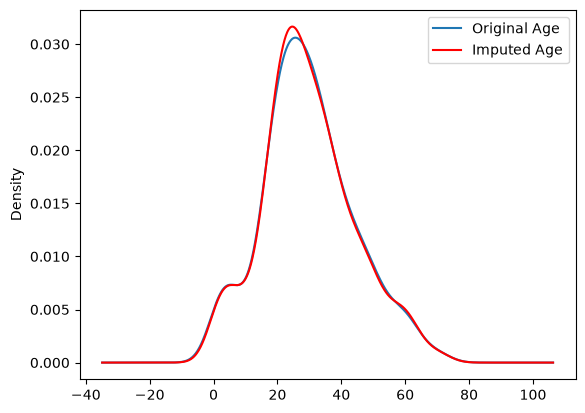

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind='kde')

X_train['Age_imputed'].plot(kind='kde',color='red')
lines,labels = ax.get_legend_handles_labels()
labels = ['Original Age','Imputed Age']
ax.legend(lines,labels,loc='best')
plt.show()

In [39]:
X_train['Age'].shape,X_train['Age_imputed'].shape

((712,), (712,))

In [41]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  203.28585569620253


In [42]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2448.197914,70.719262,51.101175
Age,70.719262,204.349513,204.349513
Age_imputed,51.101175,204.349513,203.285856


<Axes: >

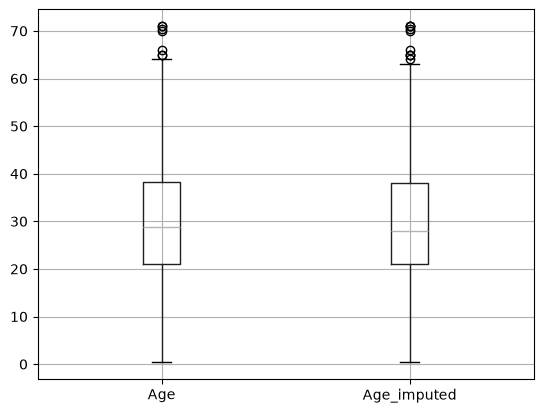

In [44]:
X_train[['Age', 'Age_imputed']].boxplot()

In [46]:
# to have the same prediction in production for a given input,
#  the value we are imputing must remain consistent with each input,
#  thus we use follwing code to keep imputation consistent for given input.

# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

In [47]:
data = pd.read_csv('housing_dataset.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [48]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [49]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [50]:
X = data
y = data['SalePrice']

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [52]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [53]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1053,Gd,TA,144500,TA,Gd
1094,NaN,TA,129000,TA,NaN
588,Gd,TA,143000,TA,Gd
888,TA,TA,268000,TA,TA
841,Po,Gd,157500,Gd,Po


In [58]:
# random imputing missing values of FireplaceQu 
X_train_missing = X_train['FireplaceQu'].isna()
X_train.loc[X_train_missing,'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train_missing.sum()).to_numpy()
X_test_missing = X_test['FireplaceQu'].isna()
X_test.loc[X_test_missing,'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_test_missing.sum()).to_numpy()

# random imputing missing values of GarageQual
X_train_missing = X_train['GarageQual'].isna()
X_train.loc[X_train_missing,'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train_missing.sum()).to_numpy()
X_test_missing = X_test['GarageQual'].isna()
X_test.loc[X_test_missing,'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_test_missing.sum()).to_numpy()

In [59]:
# # older approach to randomly impute missing values

# X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
# X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

# # X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
# X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [60]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [61]:
temp

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [62]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.645342
TA,0.412439,0.544332
Fa,0.040917,0.051627
Po,0.027823,0.037037
Ex,0.024550,0.032548


In [63]:
X_train['FireplaceQu'].dropna().unique()

<StringArray>
['TA', 'Fa', 'Gd', 'Ex', 'Po']
Length: 5, dtype: str

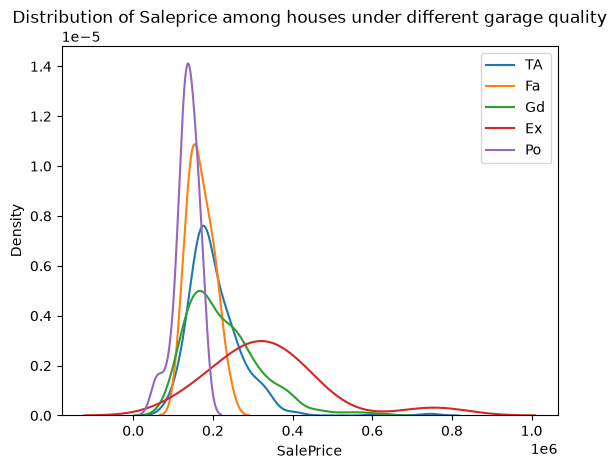

In [69]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.title("Distribution of Saleprice among houses under different garage quality")
plt.legend()
plt.show()

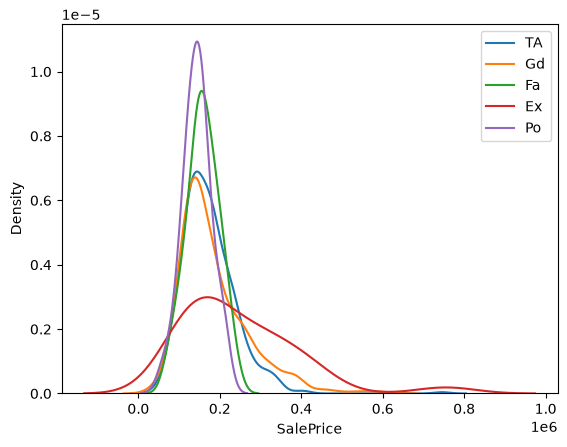

In [71]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)

plt.legend()
plt.show()